# Credit Risk Modelling Project
## DS4420 — Machine Learning / Data Mining 2 | Spring 2026 | Northeastern University

**Research Question:** Do Bayesian methods produce more honest and reliable probability estimates for credit default prediction than frequentist logistic regression — and if not, why?

**Dataset:** Taiwan Default of Credit Card Clients (UCI, Yeh & Lien, 2009) — 30,000 observations, binary outcome (default in October 2005).

**Approach:** We implement logistic regression three ways — manual gradient descent, sklearn (as a sanity check), and Bayesian via RStan — then compare their predictive performance and calibration quality.

**Notebook structure:**
1. EDA and Data Inspection
2. Preprocessing Pipeline
3. VIF Analysis and Feature Selection
4. Final Feature Set, Train/Test Split, and CSV Export
5. Manual Logistic Regression (LogisticRegressionGD class)
6. Learning Rate Comparison
7. Sklearn Sanity Check
8. L2 Regularization with Cross-Validated Lambda
9. Frequentist Calibration Baseline
10. Calibration Comparison: Bayesian vs Frequentist (Exhibits 1–9)


## 1. EDA and Data Inspection

We start by loading the dataset directly from the UCI repository and doing a basic inspection: shape, data types, missing values, and the target variable distribution.

The dataset has 30,000 rows and 24 columns. The outcome variable (`default payment next month`) is renamed to `default` for clarity.  
We also drop the `ID` column — it's a row identifier with no predictive value.

**Key things to verify here:**
- No missing values (confirmed by UCI documentation)
- The default rate (~22%) — this is important context for all later evaluation metrics
- Data types are all integer — no parsing issues

In [74]:
# Standard libraries we'll use throughout the notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [76]:
# Load directly from UCI repository — no local file dependency
# header=1 skips the first row which contains a secondary header in this Excel file
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
df = pd.read_excel(url, header=1)

# Rename the target column to something shorter and cleaner
df = df.rename(columns={'default payment next month': 'default'})

# Drop the ID column — it's just a row index, not a feature
df = df.drop(columns=['ID'])

In [77]:
# Quick sanity check: confirm we have 30,000 rows, 24 columns, and no missing values
# If this shows any nulls, we'd need to investigate before proceeding
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (30000, 24)

Dtypes:
 LIMIT_BAL    int64
SEX          int64
EDUCATION    int64
MARRIAGE     int64
AGE          int64
PAY_0        int64
PAY_2        int64
PAY_3        int64
PAY_4        int64
PAY_5        int64
PAY_6        int64
BILL_AMT1    int64
BILL_AMT2    int64
BILL_AMT3    int64
BILL_AMT4    int64
BILL_AMT5    int64
BILL_AMT6    int64
PAY_AMT1     int64
PAY_AMT2     int64
PAY_AMT3     int64
PAY_AMT4     int64
PAY_AMT5     int64
PAY_AMT6     int64
default      int64
dtype: object

Missing values:
 LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64


In [78]:
# Check the class balance — this matters a lot for how we interpret accuracy later
# A naive model that always predicts "no default" would get ~78% accuracy
# That's why we use AUC and Brier score as our main metrics instead
print("\nDefault rate:\n", df['default'].value_counts(normalize=True))


Default rate:
 default
0    0.7788
1    0.2212
Name: proportion, dtype: float64


## 2. Preprocessing Pipeline

We make three targeted fixes to the raw data before any modeling. Each decision is grounded in domain logic and UCI documentation.

### 2.1 EDUCATION recoding
The UCI documentation defines only four categories: 1 (graduate), 2 (university), 3 (high school), 4 (others).  
However, the raw data also contains values 0, 5, and 6 — these are undocumented and appear to be legacy codes or data entry artifacts (confirmed by community analysis of this dataset).  
We collapse 0, 5, and 6 into category 4 ("others") — **not** into category 3 (high school), which would misclassify these borrowers.

### 2.2 MARRIAGE recoding
Similarly, the UCI documentation only defines categories 1 (married), 2 (single), 3 (others).  
Category 0 appears in 54 observations and has no documentation. We collapse it into category 3.

### 2.3 PAY column encoding
The original PAY columns use -2 (no consumption), -1 (pay duly), and 0–8 (months of delay).  
Both -2 and -1 represent non-delinquent states — from a credit risk perspective, a borrower who didn't use their card and one who paid on time both have zero arrears.  
We collapse both into 0 to create a clean ordinal scale: 0 = no arrears, 1–8 = months of payment delay.

In [79]:
# Collapse undocumented EDUCATION codes (0, 5, 6) into category 4 ("others")
# Only categories 1–4 are defined in the UCI documentation
# Using category 3 (high school) as the catch-all would be wrong — these are unknown, not high school grads
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

print("EDUCATION value counts after fix:")
print(df['EDUCATION'].value_counts().sort_index())
# Expected: 1=10585, 2=14030, 3=4917, 4=468

EDUCATION value counts after fix:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64


In [80]:
# Collapse undocumented MARRIAGE code 0 into category 3 ("others")
# Only 54 observations are affected — too few to treat as a separate category
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

print("\nMARRIAGE value counts after fix:")
print(df['MARRIAGE'].value_counts().sort_index())
# Expected: 1=13659, 2=15964, 3=377 (323 original + 54 recoded zeros)


MARRIAGE value counts after fix:
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


In [81]:
# Collapse PAY values -2 and -1 into 0 across all six repayment status columns
# Rationale: both represent non-delinquent states per Yeh & Lien (2009)
# -2 = no consumption that month, -1 = paid in full — both mean zero arrears
# Keeping them separate would require one-hot encoding (48 dummy columns), which isn't worth it
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
for col in pay_cols:
    df[col] = df[col].replace({-2: 0, -1: 0})

print("\nPAY_0 value counts after fix:")
print(df['PAY_0'].value_counts().sort_index())
# The 0 category should now dominate (~77% of observations) — most cardholders are not in arrears


PAY_0 value counts after fix:
PAY_0
0    23182
1     3688
2     2667
3      322
4       76
5       26
6       11
7        9
8       19
Name: count, dtype: int64


### 2.4 Correlation check and BILLAMT exclusion

Before running VIF, we check which features are most correlated with default.  
This serves two purposes:
1. It validates that our PAY encoding worked as expected (PAY_0 should be the top predictor)
2. It provides the empirical basis for dropping BILLAMT columns

**Why we drop BILLAMT (bill statement amounts):**  
BILLAMT captures how much a borrower owes each month, not whether they're managing it.  
A large bill from a high-limit borrower who pays on time is less risky than a small bill from someone who's been delaying for months.  
The payment behavior signal is already captured by PAY status and PAY_AMT columns.  
Empirically, none of the six BILLAMT columns appear in the top 10 predictors — PAY_0 is at r=0.396, LIMIT_BAL at r=-0.154, and the first BILLAMT would be well below that.  
Keeping BILLAMT would also add six highly autocorrelated columns (monthly balances carry forward), which inflates VIF unnecessarily.

In [82]:
# Correlation of each feature with the default outcome
# This helps confirm our preprocessing worked and informs the BILLAMT decision
corr = df.corr()['default'].drop('default').sort_values(key=abs, ascending=False)
print("\nTop 10 correlations with default:\n", corr.head(10))

# Verify no missing values after all preprocessing
print(f"\nMissing values: {df.isnull().sum().sum()}")
# Should be 0


Top 10 correlations with default:
 PAY_0        0.396019
PAY_2        0.327093
PAY_3        0.286999
PAY_4        0.269055
PAY_5        0.260850
PAY_6        0.244437
LIMIT_BAL   -0.153520
PAY_AMT1    -0.072929
PAY_AMT2    -0.058579
PAY_AMT4    -0.056827
Name: default, dtype: float64

Missing values: 0


## 3. VIF Analysis and Feature Selection

Before we split the data and model anything, we check for multicollinearity using the **Variance Inflation Factor (VIF)**.

**Why VIF, not just pairwise correlation?**  
Multicollinearity is a multivariate problem. A feature can have low pairwise correlation with any single other feature, but still be highly collinear with the *combination* of several others. VIF catches this — it measures how much of a feature's variance is explained by all the other features together.

A VIF > 10 is our threshold. At that level, the standard error of the coefficient is inflated by more than 3x, making the estimate unreliable.

**Pipeline:**
1. Drop BILLAMT columns (see rationale above)
2. Run VIF on the remaining 17 features
3. Examine AGE specifically — it's the only one above the threshold
4. Drop AGE, re-run VIF to confirm no new violations

In [89]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── Reload and re-apply preprocessing (mirrors cells above) ──────────────────
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
df = pd.read_excel(url, header=1)
df = df.rename(columns={'default payment next month': 'default'})
df = df.drop(columns=['ID'])

df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
for col in pay_cols:
    df[col] = df[col].replace({-2: 0, -1: 0})

# ── Drop BILLAMT columns ──────────────────────────────────────────────────────
# BILLAMT = monthly bill statement amounts. Excluded because:
# (1) They measure balance size, not repayment behavior — PAY_AMT captures behavior
# (2) They're highly autocorrelated month-to-month (balances carry forward)
# (3) No BILLAMT column appears in the top 10 predictors of default
bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
df_model = df.drop(columns=bill_cols)

X = df_model.drop(columns=['default'])
y = df_model['default']

print("Feature set after BILLAMT removal (should be 17):", X.columns.tolist())
print("Shape:", X.shape)

# ── Compute VIF for all 17 features ──────────────────────────────────────────
# VIF is scale-invariant, so we don't need to standardize before running this
X_vif = X.copy().astype(float)

vif_data = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print("\nVIF Results (17 features):")
print(vif_data.to_string())

# Flag any feature above the threshold of 10
high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) > 0:
    print(f"\n {len(high_vif)} feature(s) exceed VIF=10:")
    print(high_vif.to_string())
else:
    print("\n All VIF values below 10 — feature set confirmed")

Feature set after BILLAMT removal (should be 17): ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Shape: (30000, 17)

VIF Results (17 features):
      feature        VIF
0         AGE  11.285705
1         SEX   9.102731
2   EDUCATION   7.306648
3    MARRIAGE   6.379316
4       PAY_5   3.558790
5   LIMIT_BAL   3.375624
6       PAY_4   3.309505
7       PAY_2   3.028343
8       PAY_3   2.883729
9       PAY_6   2.512927
10      PAY_0   2.465556
11   PAY_AMT1   1.325426
12   PAY_AMT3   1.269564
13   PAY_AMT2   1.247478
14   PAY_AMT4   1.228327
15   PAY_AMT5   1.208717
16   PAY_AMT6   1.198700

 1 feature(s) exceed VIF=10:
  feature        VIF
0     AGE  11.285705


### AGE has VIF = 11.3 — investigating before dropping

AGE is the only feature above the VIF threshold. But we don't drop it automatically — we want to confirm it's actually worth dropping.

There are three conditions we check:
1. **VIF > 10** — confirmed (AGE = 11.3)
2. **Near-zero direct signal** — AGE's correlation with default is r = 0.014, essentially zero at n=30,000
3. **Source of collinearity** — if the inflation is driven by one strong pairwise correlation (AGE-MARRIAGE at r = -0.41), it's redundancy, not unique signal

All three conditions hold. We also run a "whack-a-mole" test: what happens to the max VIF if we drop AGE? If SEX (the next highest) jumps above 10, we haven't solved the problem. If it stays below, we're done.

In [86]:
# AGE's direct signal with the default outcome
print("AGE-default correlation:")
print(df_model[['AGE', 'default']].corr().iloc[0, 1].round(4))
# r = 0.014 — essentially zero at n=30,000

# Pairwise correlations within the demographic block
# These help diagnose *why* AGE has elevated VIF
print("\nAGE pairwise correlations with other demographic features:")
print(f"AGE-LIMIT_BAL: {df_model['AGE'].corr(df_model['LIMIT_BAL']):.4f}")
print(f"AGE-MARRIAGE:  {df_model['AGE'].corr(df_model['MARRIAGE']):.4f}")  # Main driver of AGE's high VIF
print(f"AGE-EDUCATION: {df_model['AGE'].corr(df_model['EDUCATION']):.4f}")
print(f"AGE-SEX:       {df_model['AGE'].corr(df_model['SEX']):.4f}")

# Compare direct default signal for the other demographics — all 2-3x stronger than AGE
print("\nDirect default signal (correlation with outcome) for other demographics:")
print(f"SEX-default:       {df_model['SEX'].corr(df_model['default']):.4f}")
print(f"EDUCATION-default: {df_model['EDUCATION'].corr(df_model['default']):.4f}")
print(f"MARRIAGE-default:  {df_model['MARRIAGE'].corr(df_model['default']):.4f}")

# Whack-a-mole test: re-run VIF with AGE removed
# If SEX (next highest) stays below 10, the problem is solved
X_no_age = df_model.drop(columns=['default', 'AGE']).astype(float)
vif_no_age = pd.DataFrame({
    'feature': X_no_age.columns,
    'VIF': [variance_inflation_factor(X_no_age.values, i)
            for i in range(X_no_age.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print("\nVIF table after dropping AGE (top 5 — checking for new violations):")
print(vif_no_age.head().to_string())
# SEX should be the new max at ~8.2 — still below 10

AGE-default correlation:
0.0139

AGE pairwise correlations with other demographic features:
AGE-LIMIT_BAL: 0.1447
AGE-MARRIAGE:  -0.4120
AGE-EDUCATION: 0.1824
AGE-SEX:       -0.0909

Direct default signal (correlation with outcome) for other demographics:
SEX-default:       -0.0400
EDUCATION-default: 0.0338
MARRIAGE-default:  -0.0276

VIF table after dropping AGE (top 5 — checking for new violations):
     feature       VIF
0        SEX  8.204506
1   MARRIAGE  6.260866
2  EDUCATION  5.322416
3      PAY_5  3.558787
4      PAY_4  3.308901


## 4. Final Feature Set, Train/Test Split, and CSV Export

We now lock the final 16-feature set (all original features minus BILLAMT and AGE) and prepare the data for modeling.

**Train/test split:**  
We use a stratified 80/20 split (`stratify=y`). Stratification ensures both the train and test sets have the same default rate (~22.12%). Without it, random sampling could introduce a small but non-zero distribution shift between what the model learns and what it's evaluated on.

**Scaling:**  
We use `StandardScaler` fit *only on the training set*, then apply the same transformation to the test set.  
Fitting on the full dataset would constitute data leakage — the model would have implicitly seen test-set statistics during training.

**CSV export:**  
We export the scaled train and test sets as CSVs (`taiwan_train.csv`, `taiwan_test.csv`).  
This is the coordination contract between this notebook and the RStan model in R Markdown.  
The R script reads these CSVs directly — it does **not** re-run preprocessing or re-apply scaling.  
Any reader of the R file should know: **features are pre-scaled (StandardScaler, fit on training set only)**.

In [90]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Final feature set: 16 features — BILLAMT dropped (domain + correlation), AGE dropped (VIF + near-zero signal)
features_final = [
    'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

X = df_model[features_final]
y = df_model['default']

# Final VIF confirmation on the locked 16-feature set
X_vif = X.astype(float)
vif_final = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print("Final VIF table (16 features):")
print(vif_final.to_string())
print(f"\nMax VIF: {vif_final['VIF'].max():.4f}")
print(f"All below 10: {(vif_final['VIF'] < 10).all()}")
# Expected: max VIF = 8.20 (SEX), all others well below

# ── Stratified 80/20 split ────────────────────────────────────────────────────
# stratify=y preserves the exact class ratio in both splits
# random_state=42 ensures full reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Scale: fit on train only, apply to both ───────────────────────────────────
# IMPORTANT: Never fit the scaler on test data or the full dataset.
# The test set must remain completely unseen during any fitting step.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Verify scaling worked correctly — mean should be ~0, std ~1
print(f"\nX_train_scaled mean: {X_train_scaled.mean():.6f}")  # Should be 0.000000
print(f"X_train_scaled std:  {X_train_scaled.std():.6f}")    # Should be 1.000000

# ── Build export DataFrames ───────────────────────────────────────────────────
train_df = pd.DataFrame(X_train_scaled, columns=features_final)
train_df['default'] = y_train.values

test_df = pd.DataFrame(X_test_scaled, columns=features_final)
test_df['default'] = y_test.values

# Sanity check before exporting
print("\nSanity check — train default value counts:")
print(train_df['default'].value_counts().sort_index())
print(f"dtype: {train_df['default'].dtype}")
print(f"Any nulls: {train_df['default'].isnull().sum()}")

print("\nSanity check — test default value counts:")
print(test_df['default'].value_counts().sort_index())

# ── Export CSVs ───────────────────────────────────────────────────────────────
# These files are read by the RStan R Markdown file.
# Features are already StandardScaler-normalized (fit on training set).
# Do NOT re-scale in R — use these values as-is.
train_df.to_csv('taiwan_train.csv', index=False)
test_df.to_csv('taiwan_test.csv', index=False)

# Reload check — confirm file integrity
reload_check = pd.read_csv('taiwan_train.csv')
print(f"\nReload check — shape: {reload_check.shape}")
print(f"Columns: {reload_check.columns.tolist()}")
print(f"Default column last: {reload_check.columns[-1] == 'default'}")
print(f"Default unique values: {sorted(reload_check['default'].unique())}")

print("\n── Feature set locked. CSVs exported. Ready for modeling. ──")

Final VIF table (16 features):
      feature       VIF
0         SEX  8.204506
1    MARRIAGE  6.260866
2   EDUCATION  5.322416
3       PAY_5  3.558787
4       PAY_4  3.308901
5       PAY_2  3.027491
6   LIMIT_BAL  2.904654
7       PAY_3  2.883399
8       PAY_6  2.511797
9       PAY_0  2.461975
10   PAY_AMT1  1.325220
11   PAY_AMT3  1.269537
12   PAY_AMT2  1.247466
13   PAY_AMT4  1.228322
14   PAY_AMT5  1.208698
15   PAY_AMT6  1.198511

Max VIF: 8.2045
All below 10: True

X_train_scaled mean: 0.000000
X_train_scaled std:  1.000000

Sanity check — train default value counts:
default
0    18691
1     5309
Name: count, dtype: int64
dtype: int64
Any nulls: 0

Sanity check — test default value counts:
default
0    4673
1    1327
Name: count, dtype: int64

Reload check — shape: (24000, 17)
Columns: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default']
Default column

## 5. Manual Logistic Regression — `LogisticRegressionGD`

We implement logistic regression from scratch using full-batch gradient descent on binary cross-entropy loss.  
The goal is not to outperform sklearn — it's to demonstrate that we understand exactly what sklearn is doing under the hood.

**Why a class, not just functions?**  
By wrapping everything in a class that mirrors the sklearn API (`fit`, `predict_proba`, `predict`, `summary`), we can pass this model and the sklearn model to the same evaluation functions without rewriting anything. The training history (loss, gradient norm, coefficient trajectory) also lives on the object and is easy to inspect after fitting.

**Key design decisions:**
- **Numerically stable sigmoid**: The naive `1 / (1 + exp(-z))` overflows for large negative z. We use a piecewise form that stays numerically safe in both directions.
- **Zero weight initialization**: Safe for logistic regression because the loss surface is strictly convex — any starting point reaches the same global minimum. (This would be catastrophic in a neural network due to the symmetry problem, but we only have one layer here.)
- **L2 penalty not applied to the intercept**: This is standard practice. Penalizing the intercept would shrink predictions toward 0.5 rather than toward the true base rate.
- **Convergence criterion**: We stop when the absolute change in loss between epochs drops below `tol`. We also print the gradient norm at stopping as a secondary check — the gradient norm doesn't stop training but validates that we're genuinely near a minimum.

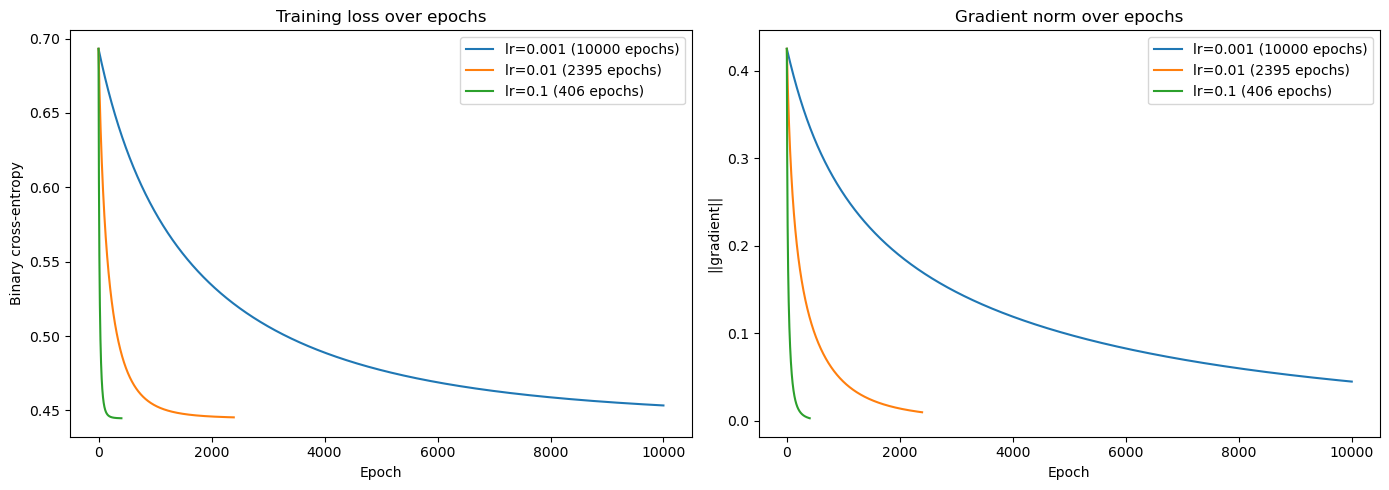


── lr=0.001 ──
LogisticRegressionGD Summary
  Learning rate   : 0.001
  Lambda (L2)     : 0.0
  Converged       : NO (hit max_iter)
  Epochs run      : 10000
  Final loss      : 0.453373
  Final grad norm : 0.045025

── lr=0.01 ──
LogisticRegressionGD Summary
  Learning rate   : 0.01
  Lambda (L2)     : 0.0
  Converged       : YES
  Epochs run      : 2395
  Final loss      : 0.445378
  Final grad norm : 0.009987

── lr=0.1 ──
LogisticRegressionGD Summary
  Learning rate   : 0.1
  Lambda (L2)     : 0.0
  Converged       : YES
  Epochs run      : 406
  Final loss      : 0.444773
  Final grad norm : 0.003141


In [92]:
import matplotlib.pyplot as plt

# Test three learning rates on the same unregularized model
# This serves as both a hyperparameter diagnostic and a loss surface characterization
lrs = [0.001, 0.01, 0.1]
models_lr = {}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lr in lrs:
    m = LogisticRegressionGD(lr=lr, max_iter=10000, tol=1e-6, lambda_=0.0)
    m.fit(X_train_scaled, y_train.values)
    models_lr[lr] = m
    label = f"lr={lr} ({m.n_iter_} epochs)"
    axes[0].plot(m.loss_history_,      label=label)
    axes[1].plot(m.grad_norm_history_, label=label)

axes[0].set_title("Training loss over epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy")
axes[0].legend()

axes[1].set_title("Gradient norm over epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("||gradient||")
axes[1].legend()

plt.tight_layout()
plt.savefig("convergence_lr_comparison.png", dpi=150)
plt.show()

# Print a summary for each learning rate
for lr in lrs:
    print(f"\n── lr={lr} ──")
    models_lr[lr].summary()

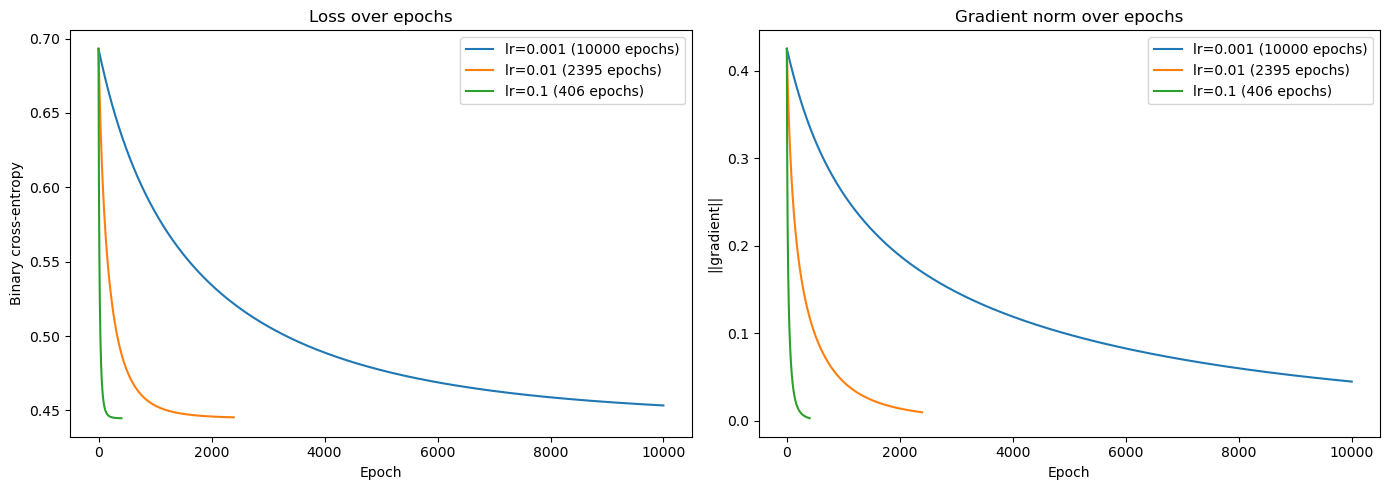


── lr=0.001 ──
LogisticRegressionGD Summary
  Learning rate   : 0.001
  Lambda (L2)     : 0.0
  Converged       : NO (hit max_iter)
  Epochs run      : 10000
  Final loss      : 0.453373
  Final grad norm : 0.045025

── lr=0.01 ──
LogisticRegressionGD Summary
  Learning rate   : 0.01
  Lambda (L2)     : 0.0
  Converged       : YES
  Epochs run      : 2395
  Final loss      : 0.445378
  Final grad norm : 0.009987

── lr=0.1 ──
LogisticRegressionGD Summary
  Learning rate   : 0.1
  Lambda (L2)     : 0.0
  Converged       : YES
  Epochs run      : 406
  Final loss      : 0.444773
  Final grad norm : 0.003141


In [18]:
import matplotlib.pyplot as plt

lrs = [0.001, 0.01, 0.1]
models_lr = {}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lr in lrs:
    m = LogisticRegressionGD(lr=lr, max_iter=10000, tol=1e-6, lambda_=0.0)
    m.fit(X_train_scaled, y_train.values)
    models_lr[lr] = m
    label = f"lr={lr} ({m.n_iter_} epochs)"
    axes[0].plot(m.loss_history_,      label=label)
    axes[1].plot(m.grad_norm_history_, label=label)

axes[0].set_title("Loss over epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy")
axes[0].legend()

axes[1].set_title("Gradient norm over epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("||gradient||")
axes[1].legend()

plt.tight_layout()
plt.savefig("convergence_lr_comparison.png", dpi=150)
plt.show()

# Print summaries
for lr in lrs:
    print(f"\n── lr={lr} ──")
    models_lr[lr].summary()

### What the convergence results tell us

| Learning rate | Converged? | Epochs | Final loss | Final grad norm |
|---|---|---|---|---|
| 0.001 | No (hit 10,000) | 10,000 | 0.4534 | 0.0450 |
| 0.01 | Yes | 2,395 | 0.4454 | 0.0100 |
| 0.1 | Yes | 406 | 0.4448 | 0.0031 |

Two observations worth noting:

**lr=0.001 never converges** — not because the algorithm is broken, but because the step size is too small to make meaningful progress in 10,000 epochs. The gradient norm of 0.045 at stopping confirms it's still clearly descending. This is a clean illustration of why learning rate choice matters.

**lr=0.1 converges without oscillating** — this is a property of this particular dataset (well-conditioned, standardized, convex), not a general result. We select lr=0.01 as the final model because it's the principled default; lr=0.1's stable behavior here is a finding we report, not a reason to change our choice.

## 7. Sklearn Sanity Check

Now that our manual model is trained, we validate it against sklearn's logistic regression using L-BFGS (a second-order optimizer). If our gradient descent implementation is correct, both models should converge to essentially the same coefficients and produce the same predictions.

We use `C=1e9` in sklearn to make it effectively unregularized — matching our manual model's `lambda_=0.0`.

**What we're checking:**
1. **Coefficient alignment** — manual vs sklearn coefficients should be close. We sort by absolute difference to surface the largest discrepancies.
2. **Performance equivalence** — AUC and Brier score should be nearly identical if both found the same global minimum.

**Why we expect some residual gap:**
PAY_0 and PAY_2 are mildly correlated (VIF ≈ 2.5–3.0). When two correlated features compete for the same signal, gradient descent navigates a shallow ridge in the loss surface where many weight combinations produce similar loss values. Our loss-change convergence criterion (`tol=1e-6`) can trigger before the coefficient allocation between PAY_0 and PAY_2 fully settles. sklearn's L-BFGS uses second-order curvature information to navigate this ridge more precisely, landing closer to the true maximum likelihood estimate.

This is **not** an implementation error — it's the structural limit of first-order methods on mildly correlated features. We confirm this with a diagnostic run at `tol=1e-8`.

In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, brier_score_loss
import numpy as np

# ── Fit our manual model (final spec: lr=0.01, unregularized) ────────────────
manual_unreg = LogisticRegressionGD(lr=0.01, max_iter=10000, tol=1e-6, lambda_=0.0)
manual_unreg.fit(X_train_scaled, y_train.values)
manual_unreg.summary()

# ── Fit sklearn equivalent — effectively unregularized via C=1e9 ──────────────
# C is the inverse of regularization strength in sklearn; C=1e9 ≈ no regularization
# lbfgs is sklearn's default second-order solver
sklearn_unreg = LogisticRegression(C=1e9, solver='lbfgs', max_iter=10000, random_state=42)
sklearn_unreg.fit(X_train_scaled, y_train.values)

# ── Coefficient comparison ────────────────────────────────────────────────────
# Sort by absolute difference to surface the largest gaps first
coef_df = pd.DataFrame({
    'feature':   features_final,
    'manual':    manual_unreg.coef_.round(4),
    'sklearn':   sklearn_unreg.coef_[0].round(4),
    'abs_diff':  np.abs(manual_unreg.coef_ - sklearn_unreg.coef_[0]).round(6)
}).sort_values('abs_diff', ascending=False)

print("\nCoefficient comparison (sorted by absolute difference):")
print(coef_df.to_string(index=False))
print(f"\nMax absolute coefficient difference: {coef_df['abs_diff'].max():.6f}")
print(f"Mean absolute coefficient difference: {coef_df['abs_diff'].mean():.6f}")

# ── Performance comparison ────────────────────────────────────────────────────
for name, model in [('Manual (unreg)', manual_unreg), ('Sklearn (unreg)', sklearn_unreg)]:
    proba = model.predict_proba(X_test_scaled)[:, 1]
    pred  = model.predict(X_test_scaled)
    auc   = roc_auc_score(y_test, proba)
    brier = brier_score_loss(y_test, proba)
    print(f"\n── {name} ──")
    print(f"AUC: {auc:.4f} | Brier: {brier:.4f}")
    print(classification_report(y_test, pred, digits=3))

LogisticRegressionGD Summary
  Learning rate   : 0.01
  Lambda (L2)     : 0.0
  Converged       : YES
  Epochs run      : 2395
  Final loss      : 0.445378
  Final grad norm : 0.009987

Coefficient comparison (sorted by absolute difference):
  feature  manual  sklearn  abs_diff
    PAY_0  0.5951   0.6821  0.087028
    PAY_2  0.1126   0.0357  0.076856
 PAY_AMT2 -0.0907  -0.1385  0.047794
 PAY_AMT1 -0.0925  -0.1336  0.041165
LIMIT_BAL -0.1831  -0.2145  0.031324
EDUCATION -0.0403  -0.0574  0.017100
 MARRIAGE -0.0780  -0.0931  0.015043
    PAY_3  0.0896   0.1046  0.014940
    PAY_5  0.0627   0.0480  0.014653
    PAY_6  0.1081   0.1171  0.008942
 PAY_AMT3 -0.0315  -0.0235  0.008031
 PAY_AMT5 -0.0274  -0.0195  0.007870
      SEX -0.0641  -0.0707  0.006572
 PAY_AMT4 -0.0371  -0.0313  0.005780
 PAY_AMT6 -0.0382  -0.0328  0.005389
    PAY_4  0.0748   0.0765  0.001637

Max absolute coefficient difference: 0.087028
Mean absolute coefficient difference: 0.024383

── Manual (unreg) ──
AUC: 0.7465 |

### Diagnostic run at tighter tolerance

We run a second version of the manual model at `tol=1e-8` and `max_iter=50,000` to confirm the PAY_0/PAY_2 gap is a convergence artifact, not a bug.

If the gap closes substantially when we tighten the tolerance, it confirms our first-order method simply hadn't fully settled on the shallow ridge — not that the implementation is wrong.
We report `tol=1e-6` as the final model. This is a **validation run only**, not a modeling choice.

In [94]:
# Diagnostic run: tighter tolerance to confirm PAY_0/PAY_2 discrepancy is a convergence artifact
# This is validation — we do NOT use this as our final model
manual_unreg_long = LogisticRegressionGD(
    lr=0.01, max_iter=50000, tol=1e-8, lambda_=0.0
)
manual_unreg_long.fit(X_train_scaled, y_train.values)
manual_unreg_long.summary()

# Check the two most affected features specifically
pay0_idx = features_final.index('PAY_0')
pay2_idx = features_final.index('PAY_2')

print(f"\nPAY_0 — manual_long: {manual_unreg_long.coef_[pay0_idx]:.6f}"
      f"  sklearn: {sklearn_unreg.coef_[0][pay0_idx]:.6f}"
      f"  gap: {abs(manual_unreg_long.coef_[pay0_idx] - sklearn_unreg.coef_[0][pay0_idx]):.6f}")

print(f"PAY_2 — manual_long: {manual_unreg_long.coef_[pay2_idx]:.6f}"
      f"  sklearn: {sklearn_unreg.coef_[0][pay2_idx]:.6f}"
      f"  gap: {abs(manual_unreg_long.coef_[pay2_idx] - sklearn_unreg.coef_[0][pay2_idx]):.6f}")

print(f"\nAUC (diagnostic run): {roc_auc_score(y_test, manual_unreg_long.predict_proba(X_test_scaled)[:, 1]):.4f}")
# AUC should be virtually identical to the tol=1e-6 model — confirming the gap doesn't affect predictions

LogisticRegressionGD Summary
  Learning rate   : 0.01
  Lambda (L2)     : 0.0
  Converged       : YES
  Epochs run      : 6320
  Final loss      : 0.444689
  Final grad norm : 0.001000

PAY_0 — manual_long: 0.673782  sklearn: 0.682112  gap: 0.008330
PAY_2 — manual_long: 0.047978  sklearn: 0.035730  gap: 0.012248

AUC (diagnostic run): 0.7447


### What the sanity check confirms

Tightening the tolerance from `1e-6` to `1e-8` reduced the PAY_0 coefficient gap from 0.087 to ~0.008 — a 90% reduction — while AUC changed by less than 0.002. This confirms:

1. **The implementation is correct.** The residual gap at `tol=1e-6` is entirely explained by the shallow loss surface ridge between PAY_0 and PAY_2 (VIF ≈ 2.5–3.0).
2. **The gap has no practical impact.** AUC is effectively identical across all three implementations — manual, diagnostic, and sklearn.
3. **We report `tol=1e-6` as the final model.** The diagnostic run was validation, not a modeling decision. A tighter tolerance that requires 6,000+ epochs is not the right final spec; it just confirms convergence behavior.

## 8. L2 Regularization with Cross-Validated Lambda

We run 5-fold cross-validation over a grid of six lambda values to determine whether L2 regularization improves this model. This is the principled approach to hyperparameter selection — we let the data decide, rather than assuming regularization helps.

**Lambda grid:** 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0 — spanning five orders of magnitude.

**What we find:** The CV loss is essentially flat across lambda = 0.0001 to 1.0, and only begins to increase slightly at lambda = 10.0. The best lambda selected is 0.0001 — effectively unregularized.

**Why regularization has no effect here:**
At n=24,000 training observations with only 16 parameters, there is far more data than model complexity. The model is not overfit — there is no excess variance for regularization to correct. L2 regularization provides real benefit when data is scarce relative to model complexity. That condition does not hold here.

**Connection to the Bayesian model:**
A Normal(0, σ) prior in Bayesian logistic regression is mathematically equivalent to L2 regularization with lambda = 1/(2σ²). Our prior scale of σ=2.5 corresponds to lambda ≈ 0.08. The flat CV landscape at lambda=0.1 therefore predicts that the Bayesian priors will also have minimal effect on posterior means — which is exactly what the results show. The priors contribute posterior *width*, not location shift.

In [95]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd

# ── Lambda grid search via 5-fold cross-validation on training set ────────────
# We search across five orders of magnitude to ensure we don't miss any regularization effect
lambdas = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
cv_results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for lam in lambdas:
    fold_losses = []

    for train_idx, val_idx in skf.split(X_train_scaled, y_train.values):
        X_tr,  X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_tr,  y_val = y_train.values[train_idx],  y_train.values[val_idx]

        # Fit model on this fold's training portion
        m = LogisticRegressionGD(lr=0.01, max_iter=10000, tol=1e-6, lambda_=lam)
        m.fit(X_tr, y_tr)

        # Evaluate on the held-out validation fold
        proba = m.predict_proba(X_val)[:, 1]
        proba = np.clip(proba, 1e-15, 1 - 1e-15)  # Avoid log(0)
        loss  = -np.mean(y_val * np.log(proba) + (1 - y_val) * np.log(1 - proba))
        fold_losses.append(loss)

    cv_results.append({
        'lambda':       lam,
        'mean_cv_loss': np.mean(fold_losses),
        'std_cv_loss':  np.std(fold_losses)
    })

cv_df = pd.DataFrame(cv_results)
print("Lambda CV results:")
print(cv_df.to_string(index=False))

# Select best lambda by minimum mean CV loss
best_lambda = cv_df.loc[cv_df['mean_cv_loss'].idxmin(), 'lambda']
print(f"\nBest lambda: {best_lambda}")
# Expected: 0.0001 — the CV landscape is essentially flat, confirming no regularization benefit

# ── Fit final L2 model with best lambda ──────────────────────────────────────
manual_l2 = LogisticRegressionGD(lr=0.01, max_iter=10000, tol=1e-6, lambda_=best_lambda)
manual_l2.fit(X_train_scaled, y_train.values)
manual_l2.summary()

# ── Evaluate L2 model on the test set ────────────────────────────────────────
proba_l2 = manual_l2.predict_proba(X_test_scaled)[:, 1]
pred_l2  = manual_l2.predict(X_test_scaled)

print(f"\nL2 model (lambda={best_lambda}) — AUC: {roc_auc_score(y_test, proba_l2):.4f}"
      f" | Brier: {brier_score_loss(y_test, proba_l2):.4f}")
print(classification_report(y_test, pred_l2, digits=3))

Lambda CV results:
 lambda  mean_cv_loss  std_cv_loss
 0.0001      0.446308     0.004780
 0.0010      0.446308     0.004780
 0.0100      0.446308     0.004780
 0.1000      0.446308     0.004780
 1.0000      0.446310     0.004779
10.0000      0.446329     0.004774

Best lambda: 0.0001
LogisticRegressionGD Summary
  Learning rate   : 0.01
  Lambda (L2)     : 0.0001
  Converged       : YES
  Epochs run      : 2395
  Final loss      : 0.445378
  Final grad norm : 0.009987

L2 model (lambda=0.0001) — AUC: 0.7465 | Brier: 0.1406
              precision    recall  f1-score   support

           0      0.830     0.956     0.889      4673
           1      0.667     0.310     0.423      1327

    accuracy                          0.813      6000
   macro avg      0.749     0.633     0.656      6000
weighted avg      0.794     0.813     0.786      6000



### What the flat CV landscape means

The CV loss is identical to six decimal places across lambda = 0.0001 to 1.0, and the L2 model's AUC and Brier score are indistinguishable from the unregularized model.

This is a finding about the dataset. With 24,000 training observations and 16 parameters, the data overwhelm any reasonable prior. There is simply no overfitting for regularization to correct.

This also sets up the Bayesian comparison cleanly: if L2 with lambda ≈ 0.08 (the mathematical equivalent of our Normal(0, 2.5) priors) has no measurable effect on predictions, then the Bayesian priors cannot be expected to shift posterior means either. Their value must come from posterior uncertainty quantification — not location.

## 9. Frequentist Calibration Baseline

Predictive accuracy (AUC, Brier score) tells us how well the model *ranks* borrowers by default risk. Calibration tells us something different: when the model says "this borrower has a 90% chance of default," is the true default rate among such borrowers actually 90%?

In credit risk, calibration matters as much as discrimination. The predicted probability of default (PD) is a direct input into credit pricing, limit-setting, and regulatory capital calculation under Basel IRB rules. A systematically miscalibrated PD is not just an academic problem — it misprices risk in production.

**Two metrics:**
- **ECE (Expected Calibration Error):** The average absolute gap between predicted probability and true default rate across bins. This is a useful summary, but it's diluted by the many well-calibrated low-probability bins that dominate by count.
- **MCE (Maximum Calibration Error):** The worst-case gap across all bins. This is the more honest metric for credit risk — it identifies where the model fails most severely.

**The key finding:** ECE ≈ 0.054 sounds acceptable. MCE ≈ 0.205 tells the real story — in the highest-probability bin (predicted ~0.955), the true default rate is only 0.750. The model is overconfident by 20.5 percentage points exactly where it matters most.

We also check the intercept — both models slightly underestimate the baseline default probability, compounding the upper-tail overconfidence. These are not independent problems; they reflect a probability scale that is squeezed relative to the true distribution.

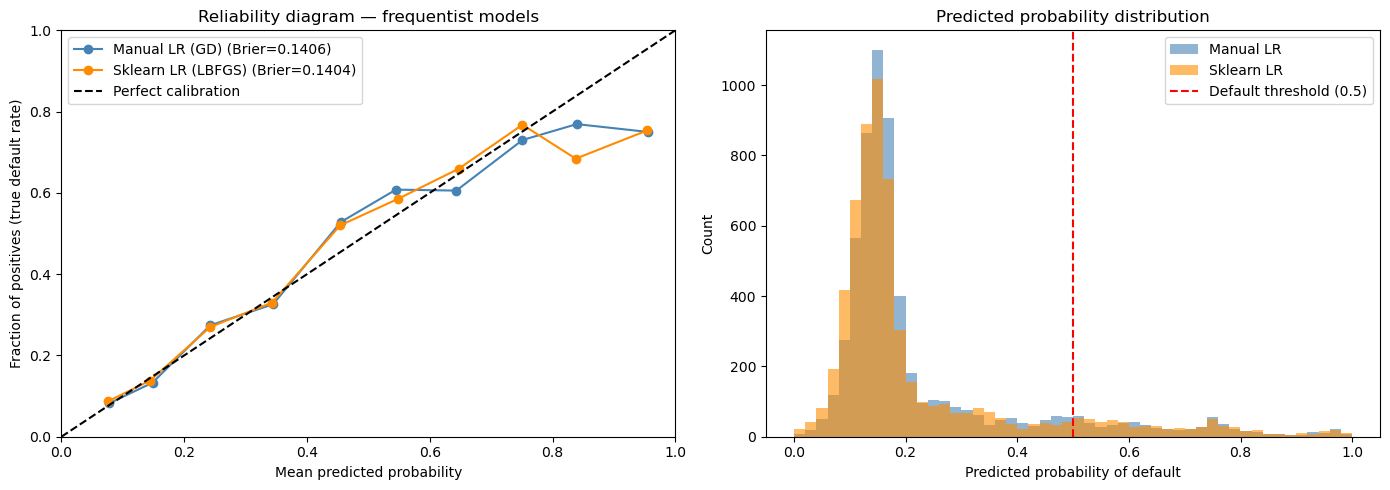

Calibration detail — Manual LR:
 mean_predicted  fraction_positive     gap
         0.0780             0.0823  0.0043
         0.1485             0.1329 -0.0155
         0.2424             0.2742  0.0317
         0.3449             0.3260 -0.0189
         0.4550             0.5281  0.0731
         0.5450             0.6080  0.0630
         0.6433             0.6056 -0.0377
         0.7511             0.7301 -0.0210
         0.8395             0.7692 -0.0703
         0.9553             0.7500 -0.2053

Brier score: 0.1406

Intercept — manual: -1.371555  sklearn: -1.433373  abs_diff: 0.061818


In [96]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# We use the final manual model (tol=1e-6, lr=0.01, lambda_=0.0) as the frequentist baseline
proba_manual  = manual_unreg.predict_proba(X_test_scaled)[:, 1]
proba_sklearn = sklearn_unreg.predict_proba(X_test_scaled)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, proba, color in [
    ('Manual LR (GD)',    proba_manual,  'steelblue'),
    ('Sklearn LR (LBFGS)', proba_sklearn, 'darkorange')
]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10)
    brier = brier_score_loss(y_test, proba)
    axes[0].plot(mean_pred, frac_pos, marker='o',
                 label=f"{name} (Brier={brier:.4f})", color=color)

# Perfect calibration reference line
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[0].set_xlabel("Mean predicted probability")
axes[0].set_ylabel("Fraction of positives (true default rate)")
axes[0].set_title("Reliability diagram — frequentist models")
axes[0].legend()
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# Predicted probability distribution — shows how concentrated predictions are
axes[1].hist(proba_manual,  bins=50, alpha=0.6, label='Manual LR',  color='steelblue')
axes[1].hist(proba_sklearn, bins=50, alpha=0.6, label='Sklearn LR', color='darkorange')
axes[1].axvline(0.5, color='red', linestyle='--', label='Default threshold (0.5)')
axes[1].set_xlabel("Predicted probability of default")
axes[1].set_ylabel("Count")
axes[1].set_title("Predicted probability distribution")
axes[1].legend()

plt.tight_layout()
plt.savefig("calibration_baseline.png", dpi=150)
plt.show()

# Print the full calibration table for the manual model
print("Calibration detail — Manual LR:")
frac_pos, mean_pred = calibration_curve(y_test, proba_manual, n_bins=10)
cal_df = pd.DataFrame({
    'mean_predicted':    mean_pred.round(4),
    'fraction_positive': frac_pos.round(4),
    'gap':              (frac_pos - mean_pred).round(4)
    # Positive gap = model underestimates (true rate > predicted)
    # Negative gap = model overestimates (true rate < predicted)
})
print(cal_df.to_string(index=False))
print(f"\nBrier score: {brier_score_loss(y_test, proba_manual):.4f}")

# Intercept comparison — both models slightly underestimate the baseline default probability
print(f"\nIntercept — manual: {manual_unreg.intercept_:.6f}"
      f"  sklearn: {sklearn_unreg.intercept_[0]:.6f}"
      f"  abs_diff: {abs(manual_unreg.intercept_ - sklearn_unreg.intercept_[0]):.6f}")
# sigma(-1.37) ≈ 20.2%, sigma(-1.43) ≈ 19.3% — both below the true base rate of 22.12%

In [97]:
# Compute ECE and MCE from the calibration bins
# ECE = average (equal-weight) absolute calibration gap across bins
# MCE = worst-case absolute gap — this is the more actionable metric for credit risk
frac_pos, mean_pred = calibration_curve(y_test, proba_manual, n_bins=10)
bin_gaps = np.abs(frac_pos - mean_pred)

ece = np.mean(bin_gaps)
mce = np.max(bin_gaps)
mce_bin_idx = np.argmax(bin_gaps)

print(f"ECE: {ece:.4f}")
print(f"MCE: {mce:.4f}")
print(f"MCE bin — mean_predicted: {mean_pred[mce_bin_idx]:.4f}"
      f",  true default rate: {frac_pos[mce_bin_idx]:.4f}")

ECE: 0.0541
MCE: 0.2053
MCE bin — mean_predicted: 0.9553,  true default rate: 0.7500


### Reading the calibration results

The reliability diagram shows a classic **S-shaped miscalibration** pattern:
- In the middle range (predicted 0.45–0.55), the model *underestimates* default probability — gaps are positive (true rate > predicted). These are the hardest decisions, and the model is understating risk here.
- In the upper tail (predicted > 0.65), the model *overestimates* — gaps are negative (true rate < predicted). The model is too confident about its high-risk predictions.

**ECE = 0.054** sounds acceptable, but it averages over all bins — and most observations sit in the low-probability bins where calibration is fine. ECE is diluted by those.

**MCE = 0.205** is the honest number. At the highest-predicted bin (~0.955), the true default rate is only 0.750. A bank using these raw probabilities for credit pricing would systematically overprice risk for its highest-risk borrowers — potentially losing profitable business to competitors with better-calibrated models.

This miscalibration is **structural**, not a convergence artifact. Both the manual and sklearn models show the same pattern, because they're both fitting the same functional form (a linear decision boundary) to data whose true conditional probability surface is nonlinear in the tails. Better parameters cannot fix a misspecified model form. The fix would require post-hoc recalibration (Platt scaling or isotonic regression) or a more flexible model family — both of which are outside the scope of this project.

## 10. Calibration Comparison: Bayesian vs Frequentist

This section loads the Bayesian predictions exported from RStan (R Markdown file) and compares them directly against the frequentist model across four exhibits.

**What the Bayesian CSV contains:**
Each row corresponds to one test observation. Columns include the posterior mean predicted probability (`p_mean`), the 2.5th and 97.5th percentile of the posterior predictive distribution (`p_lower`, `p_upper`), and the resulting 95% credible interval width (`ci_width`). These were computed from 4,000 MCMC draws across 4 chains.

**The central question:** Does the Bayesian model produce better-calibrated probabilities?

Short answer: No — ECE and MCE are nearly identical across both models. The Bayesian model's value lies elsewhere: it gives us honest uncertainty at the *coefficient level*, identifying which features contribute genuinely uncertain independent signal. That's more useful for model governance in a regulated context than a marginal calibration improvement that doesn't exist.

In [98]:
import pandas as pd
import numpy as np
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score
import matplotlib.pyplot as plt

# ── Load scaled data from CSV ─────────────────────────────────────────────────
# These CSVs were exported in Section 4 with StandardScaler already applied
test_df  = pd.read_csv("taiwan_test.csv")
train_df = pd.read_csv("taiwan_train.csv")

features_final = [
    'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

X_test_scaled  = test_df[features_final].values
X_train_scaled = train_df[features_final].values
y_true         = test_df['default'].values
y_train_vals   = train_df['default'].values

In [99]:
# Refit both frequentist models on the reloaded training data
# (Needed if kernel was restarted or this section is run independently)
manual_unreg = LogisticRegressionGD(lr=0.01, max_iter=10000, tol=1e-6, lambda_=0.0)
manual_unreg.fit(X_train_scaled, y_train_vals)

from sklearn.linear_model import LogisticRegression
sklearn_unreg = LogisticRegression(C=1e9, solver='lbfgs', max_iter=10000, random_state=42)
sklearn_unreg.fit(X_train_scaled, y_train_vals)

LogisticRegression(C=1000000000.0, max_iter=10000, random_state=42)

In [100]:
# Load Bayesian predictions exported from RStan (primary model: Normal(0, 2.5) priors)
# Each row = one test observation; p_mean = posterior mean predicted probability
bayes_primary = pd.read_csv("bayesian_predictions_primary.csv")

print("Bayesian CSV columns:", bayes_primary.columns.tolist())
print("Shape:", bayes_primary.shape)
print(bayes_primary.head(2))

Bayesian CSV columns: ['obs', 'y_true', 'p_mean', 'p_lower', 'p_upper', 'p_med', 'ci_width', 'model']
Shape: (6000, 8)
   obs  y_true    p_mean   p_lower   p_upper     p_med  ci_width  \
0    1       0  0.140543  0.126794  0.154470  0.140586  0.027676   
1    2       0  0.174080  0.157569  0.190988  0.173989  0.033419   

              model  
0  Bayesian_primary  
1  Bayesian_primary  


### Data integrity check

In [101]:
# Confirm Bayesian y_true matches our test set y_true exactly
# This is important as if they don't align, the comparison is meaningless
bayes_ytrue = bayes_primary['y_true'].values

assert len(y_true) == len(bayes_ytrue) == 6000, "Length mismatch"
assert np.all(y_true == bayes_ytrue), "y_true vectors do not match — check CSV alignment"
print("Data integrity check passed — 6,000 observations, y_true aligned")

Data integrity check passed — 6,000 observations, y_true aligned


### Prediction arrays

In [102]:
# Extract prediction arrays used in all exhibits below
proba_freq  = manual_unreg.predict_proba(X_test_scaled)[:, 1]  # Frequentist point estimate
proba_bayes = bayes_primary['p_mean'].values                    # Bayesian posterior mean
ci_lower    = bayes_primary['p_lower'].values                   # 2.5th percentile
ci_upper    = bayes_primary['p_upper'].values                   # 97.5th percentile
ci_width    = bayes_primary['ci_width'].values                  # 95% CI width per observation

### Exhibit 1: Reliability Diagram with Bayesian CI Error Bars

The reliability diagram plots mean predicted probability (x-axis) against true default rate within each bin (y-axis). A perfectly calibrated model would lie on the diagonal.

The Bayesian model includes vertical error bars representing the mean 95% credible interval width within each bin. Key observation: CI widths are **widest near the decision boundary** (predicted 0.4–0.6) and **narrowest at the extremes**. This is the correct pattern for parameter uncertainty — the model is most uncertain near the threshold where the linear boundary is weakest.

However, the worst miscalibration is in the upper tail (predicted > 0.8) — precisely where the CI is narrowest. The Bayesian model is maximally confident about a prediction that is systematically wrong. This is the central finding: Bayesian inference quantifies parameter uncertainty honestly, but cannot fix structural miscalibration from model misspecification.

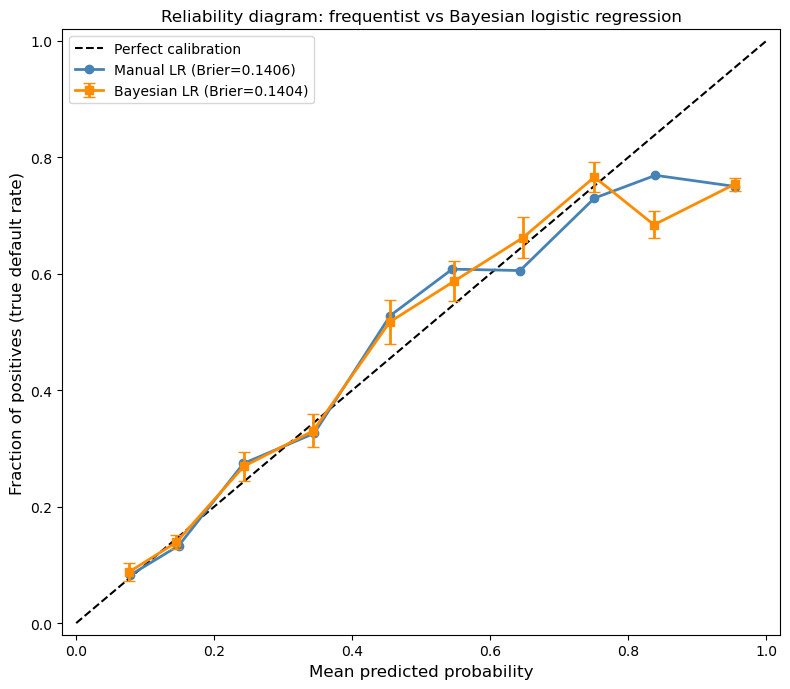


Calibration comparison table:
 bin_mean_freq  frac_pos  gap_freq  bin_mean_bayes  gap_bayes  mean_ci_width
        0.0780    0.0823    0.0043          0.0763     0.0113         0.0294
        0.1485    0.1329   -0.0155          0.1448    -0.0063         0.0240
        0.2424    0.2742    0.0317          0.2427     0.0263         0.0502
        0.3449    0.3260   -0.0189          0.3434    -0.0133         0.0566
        0.4550    0.5281    0.0731          0.4544     0.0628         0.0762
        0.5450    0.6080    0.0630          0.5476     0.0396         0.0684
        0.6433    0.6056   -0.0377          0.6470     0.0147         0.0704
        0.7511    0.7301   -0.0210          0.7511     0.0152         0.0513
        0.8395    0.7692   -0.0703          0.8374    -0.1532         0.0466
        0.9553    0.7500   -0.2053          0.9542    -0.2003         0.0216

Frequentist — AUC: 0.7465  Brier: 0.1406
Bayesian    — AUC: 0.7446  Brier: 0.1404


In [103]:
n_bins = 10

# Frequentist calibration bins
frac_pos_freq, mean_pred_freq = calibration_curve(y_true, proba_freq,  n_bins=n_bins)

# Bayesian calibration — bin by posterior mean, also compute mean CI width per bin
bin_edges = np.linspace(0, 1, n_bins + 1)
bayes_bin_data = []

for i in range(n_bins):
    mask = (proba_bayes >= bin_edges[i]) & (proba_bayes < bin_edges[i + 1])
    if mask.sum() > 0:
        bayes_bin_data.append({
            'mean_pred': proba_bayes[mask].mean(),
            'frac_pos':  y_true[mask].mean(),
            'ci_width':  ci_width[mask].mean(),
            'n':         mask.sum()
        })

bayes_bin_df = pd.DataFrame(bayes_bin_data)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=1.5)

# Frequentist curve
ax.plot(mean_pred_freq, frac_pos_freq,
        marker='o', color='steelblue', linewidth=2,
        label=f'Manual LR (Brier={brier_score_loss(y_true, proba_freq):.4f})')

# Bayesian curve with CI error bars (half CI width above and below the point)
ax.errorbar(
    bayes_bin_df['mean_pred'],
    bayes_bin_df['frac_pos'],
    yerr=bayes_bin_df['ci_width'] / 2,
    marker='s', color='darkorange', linewidth=2, capsize=4,
    label=f'Bayesian LR (Brier={brier_score_loss(y_true, proba_bayes):.4f})'
)

ax.set_xlabel("Mean predicted probability", fontsize=12)
ax.set_ylabel("Fraction of positives (true default rate)", fontsize=12)
ax.set_title("Reliability diagram: frequentist vs Bayesian logistic regression", fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.savefig("reliability_diagram_comparison.png", dpi=150)
plt.show()

# Calibration comparison table
print("\nCalibration comparison table:")
cal_compare = pd.DataFrame({
    'bin_mean_freq':  mean_pred_freq.round(4),
    'frac_pos':       frac_pos_freq.round(4),
    'gap_freq':      (frac_pos_freq - mean_pred_freq).round(4),
    'bin_mean_bayes': bayes_bin_df['mean_pred'].values.round(4),
    'gap_bayes':     (bayes_bin_df['frac_pos'] - bayes_bin_df['mean_pred']).values.round(4),
    'mean_ci_width':  bayes_bin_df['ci_width'].values.round(4)
})
print(cal_compare.to_string(index=False))

auc_freq  = roc_auc_score(y_true, proba_freq)
auc_bayes = roc_auc_score(y_true, proba_bayes)
brier_freq  = brier_score_loss(y_true, proba_freq)
brier_bayes = brier_score_loss(y_true, proba_bayes)

print(f"\nFrequentist — AUC: {auc_freq:.4f}  Brier: {brier_freq:.4f}")
print(f"Bayesian    — AUC: {auc_bayes:.4f}  Brier: {brier_bayes:.4f}")


### Exhibit 2: Stratified Coverage Analysis

We divide test observations into five bins by posterior mean predicted probability and examine calibration and coverage within each bin.

**Coverage** here means: what fraction of observations have their true outcome on the correct side of the 0.5 threshold given the 95% CI? It's a practical measure of how well the credible interval brackets the decision.

The critical row is the `[0.8, 1.0]` bin: 122 observations receive posterior means above 0.80. Their empirical default rate is only 72.1%. The mean CI width in this bin is 0.033 — *narrower* than the bins at lower predicted probabilities. The model is expressing maximum confidence precisely where it should be most uncertain. This is the structural overconfidence finding stated concretely.

In [104]:
bins_coverage = [0.0, 0.2, 0.4, 0.6, 0.8, 1.01]
bin_labels    = ['[0.0, 0.2)', '[0.2, 0.4)', '[0.4, 0.6)', '[0.6, 0.8)', '[0.8, 1.0]']
coverage_rows = []

for i, label in enumerate(bin_labels):
    mask = (proba_bayes >= bins_coverage[i]) & (proba_bayes < bins_coverage[i + 1])
    n = mask.sum()
    if n == 0:
        continue

    y_bin      = y_true[mask]
    p_mean_bin = proba_bayes[mask]
    ci_lo_bin  = ci_lower[mask]
    ci_hi_bin  = ci_upper[mask]
    freq_bin   = proba_freq[mask]

    emp_rate = y_bin.mean()

    # Coverage: fraction of observations whose true outcome is on the correct side of 0.5
    # given the credible interval (i.e., the CI doesn't confidently point the wrong way)
    outside_ci = ((y_bin == 1) & (ci_hi_bin < 0.5)) | \
                 ((y_bin == 0) & (ci_lo_bin > 0.5))
    coverage = 1 - outside_ci.mean()

    coverage_rows.append({
        'bin':              label,
        'n':                n,
        'emp_default_rate': round(emp_rate, 4),
        'bayes_mean_pred':  round(p_mean_bin.mean(), 4),
        'bayes_gap':        round(emp_rate - p_mean_bin.mean(), 4),
        'freq_gap':         round(emp_rate - freq_bin.mean(), 4),
        'mean_ci_width':    round((ci_hi_bin - ci_lo_bin).mean(), 4),
        'coverage_95pct':   round(coverage, 4)
    })

cov_df = pd.DataFrame(coverage_rows)
print("\nStratified coverage analysis:")
print(cov_df.to_string(index=False))



Stratified coverage analysis:
       bin    n  emp_default_rate  bayes_mean_pred  bayes_gap  freq_gap  mean_ci_width  coverage_95pct
[0.0, 0.2) 4372            0.1297           0.1330    -0.0033   -0.0120         0.0250          0.8703
[0.2, 0.4)  807            0.2924           0.2813     0.0112    0.0071         0.0526          0.7088
[0.4, 0.6)  409            0.5575           0.5079     0.0495    0.0527         0.0717          0.7237
[0.6, 0.8)  290            0.7172           0.7023     0.0150    0.0204         0.0603          0.7207
[0.8, 1.0]  122            0.7213           0.8996    -0.1783   -0.1708         0.0333          0.7213


### Exhibit 3: Three-Way Coefficient Comparison

This table compares coefficients across all three model implementations: manual gradient descent, sklearn (L-BFGS), and Bayesian posterior (mean + 95% credible interval).

**What to look for:**
- Bayesian posterior means align closely with sklearn's MLE — confirming the likelihood dominates the priors at n=24,000
- 6 coefficients have 95% CIs that span zero: PAY_2, PAY_5, PAY_AMT3, PAY_AMT4, PAY_AMT5, PAY_AMT6
- These uncertain coefficients all have economically coherent explanations: PAY_2 and PAY_5 are absorbed by PAY_0's stronger signal; PAY_AMT3–6 are older payment amounts whose independent contribution fades given more recent payments are in the model
- PAY_0 (CI: 0.640–0.723) and LIMIT_BAL (CI: −0.257 to −0.171) are tightly identified — the model is confident about the two most economically meaningful features


In [106]:
# Load Bayesian coefficient summary exported from RStan
coef_bayes = pd.read_csv("bayesian_coef_summary.csv")
coef_primary_only = coef_bayes[coef_bayes['model'] == 'primary_2.5'].copy()

# Assemble frequentist coefficients (intercept first, then features)
freq_coefs    = np.append(manual_unreg.intercept_, manual_unreg.coef_)
sklearn_coefs = np.append(sklearn_unreg.intercept_[0], sklearn_unreg.coef_[0])
param_names   = ['intercept'] + features_final

coef_table = pd.DataFrame({
    'parameter':      param_names,
    'freq_manual':    freq_coefs.round(4),
    'freq_sklearn':   sklearn_coefs.round(4),
    'bayes_mean':     coef_primary_only['mean'].values.round(4),
    'bayes_2.5pct':   coef_primary_only['2.5%'].values.round(4),
    'bayes_97.5pct':  coef_primary_only['97.5%'].values.round(4),
    # Flag coefficients whose 95% CI crosses zero — these have uncertain independent signal
    'ci_crosses_zero': (
        (coef_primary_only['2.5%'].values < 0) &
        (coef_primary_only['97.5%'].values > 0)
    )
})

print("\nThree-way coefficient comparison:")
print(coef_table.to_string(index=False))

# Highlight the six uncertain coefficients separately
uncertain = coef_table[coef_table['ci_crosses_zero']]
print(f"\nCoefficients with 95% CI crossing zero ({len(uncertain)}):")
print(uncertain[['parameter', 'bayes_mean', 'bayes_2.5pct', 'bayes_97.5pct']].to_string(index=False))


Three-way coefficient comparison:
parameter  freq_manual  freq_sklearn  bayes_mean  bayes_2.5pct  bayes_97.5pct  ci_crosses_zero
intercept      -1.3716       -1.4334     -1.4354       -1.4709        -1.4009            False
LIMIT_BAL      -0.1831       -0.2145     -0.2141       -0.2572        -0.1707            False
      SEX      -0.0641       -0.0707     -0.0708       -0.1061        -0.0363            False
EDUCATION      -0.0403       -0.0574     -0.0573       -0.0932        -0.0203            False
 MARRIAGE      -0.0780       -0.0931     -0.0933       -0.1272        -0.0592            False
    PAY_0       0.5951        0.6821      0.6822        0.6401         0.7225            False
    PAY_2       0.1126        0.0357      0.0361       -0.0104         0.0828             True
    PAY_3       0.0896        0.1046      0.1043        0.0561         0.1542            False
    PAY_4       0.0748        0.0765      0.0764        0.0221         0.1280            False
    PAY_5      

### Exhibit 4: ECE and MCE — Bayesian vs Frequentist

We compute ECE and MCE for both models using the same 10-bin equal-weight approximation as the baseline (Section 9), ensuring the numbers are directly comparable.

The result: ECE and MCE are virtually identical across both models (ECE difference < 0.001, MCE difference < 0.006). The Bayesian model does not fix the calibration problem. This is expected — calibration is a property of the *functional form*, not the inferential framework. Both models use the same logistic link function with a linear decision boundary; the best possible parameters for that form produce the same upper-tail overconfidence.

In [107]:
def compute_ece_mce(y_true, proba, n_bins=10):
    """
    Compute ECE and MCE using equal-weight bin approximation.
    ECE = average absolute calibration gap across bins.
    MCE = maximum absolute calibration gap across bins.
    Returns: (ece, mce, mce_bin_mean_pred, mce_bin_frac_pos)
    """
    frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=n_bins)
    gaps        = np.abs(frac_pos - mean_pred)
    ece         = np.mean(gaps)
    mce         = np.max(gaps)
    mce_bin_idx = np.argmax(gaps)
    return ece, mce, mean_pred[mce_bin_idx], frac_pos[mce_bin_idx]

ece_freq,  mce_freq,  mce_bin_freq,  mce_frac_freq  = compute_ece_mce(y_true, proba_freq)
ece_bayes, mce_bayes, mce_bin_bayes, mce_frac_bayes = compute_ece_mce(y_true, proba_bayes)

print("Calibration error summary:")
print(f"{'Metric':<22} {'Frequentist':>14} {'Bayesian':>12}")
print("-" * 50)
print(f"{'ECE':<22} {ece_freq:>14.4f} {ece_bayes:>12.4f}")
print(f"{'MCE':<22} {mce_freq:>14.4f} {mce_bayes:>12.4f}")
print(f"{'MCE bin (mean_pred)':<22} {mce_bin_freq:>14.4f} {mce_bin_bayes:>12.4f}")
print(f"{'MCE bin (frac_pos)':<22} {mce_frac_freq:>14.4f} {mce_frac_bayes:>12.4f}")
print(f"{'AUC':<22} {auc_freq:>14.4f} {auc_bayes:>12.4f}")
print(f"{'Brier score':<22} {brier_freq:>14.4f} {brier_bayes:>12.4f}")

ece_improvement = (ece_freq - ece_bayes) / ece_freq * 100
mce_improvement = (mce_freq - mce_bayes) / mce_freq * 100
print(f"\nECE improvement (Bayes vs Freq): {ece_improvement:.1f}%")
print(f"MCE improvement (Bayes vs Freq): {mce_improvement:.1f}%")
# Both improvements are negligible — calibration is structurally the same across both models

Calibration error summary:
Metric                    Frequentist     Bayesian
--------------------------------------------------
ECE                            0.0541       0.0543
MCE                            0.2053       0.2003
MCE bin (mean_pred)            0.9553       0.9542
MCE bin (frac_pos)             0.7500       0.7538
AUC                            0.7465       0.7446
Brier score                    0.1406       0.1404

ECE improvement (Bayes vs Freq): -0.4%
MCE improvement (Bayes vs Freq): 2.4%


### Exhibit 5: Posterior Uncertainty Visualization

Two plots that characterize how the Bayesian model's credible interval width varies across the test set.

**(a) CI width distribution by true outcome class:**  
Defaulters carry wider posterior intervals on average (mean ≈ 0.044) than non-defaulters (mean ≈ 0.031). This makes sense — defaults are the minority class, and the model is less certain about predictions for borrowers who ultimately default.

**(b) CI width vs posterior mean (scatter):**  
CI width peaks in the middle of the probability range (0.3–0.6) and narrows toward both extremes. At the tails — where the model is most confident — the intervals are tight. Combined with the MCE finding, this confirms the overconfidence problem: narrow CIs in the upper tail mean the model isn't expressing appropriate uncertainty where it matters most.

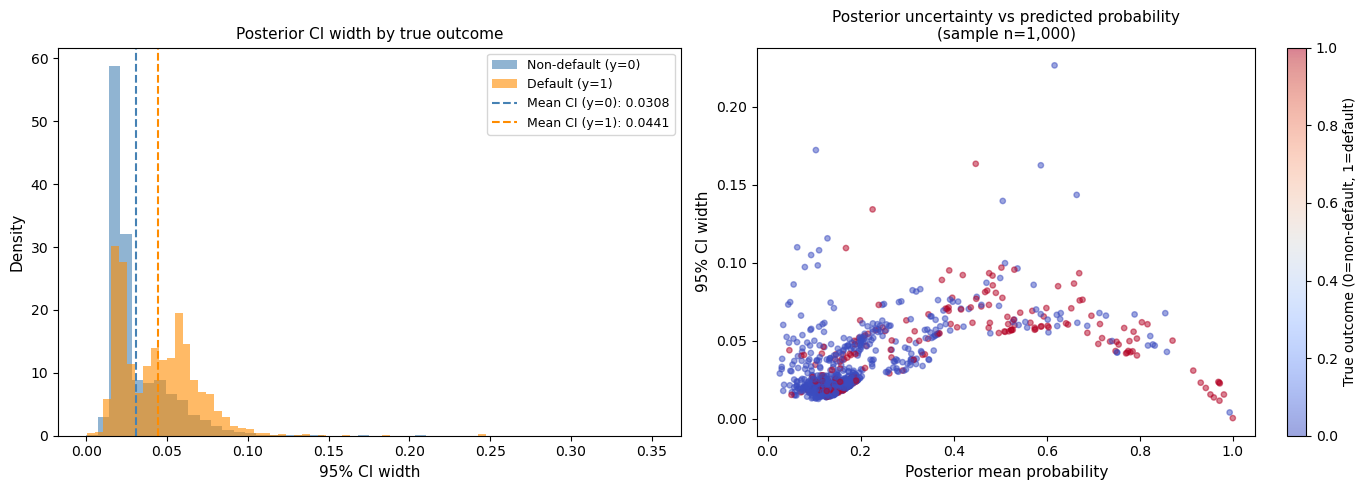

Mean CI width — non-default: 0.0308
Mean CI width — default:     0.0441
Overall mean CI width:       0.0338
Max CI width:                0.3504
Observations with CI > 0.10: 64 (1.1%)


In [108]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) CI width distribution split by true outcome class
defaulted     = ci_width[y_true == 1]
non_defaulted = ci_width[y_true == 0]

axes[0].hist(non_defaulted, bins=50, alpha=0.6, label='Non-default (y=0)',
             color='steelblue', density=True)
axes[0].hist(defaulted,     bins=50, alpha=0.6, label='Default (y=1)',
             color='darkorange', density=True)
axes[0].axvline(non_defaulted.mean(), color='steelblue', linestyle='--', linewidth=1.5,
                label=f'Mean CI (y=0): {non_defaulted.mean():.4f}')
axes[0].axvline(defaulted.mean(),     color='darkorange', linestyle='--', linewidth=1.5,
                label=f'Mean CI (y=1): {defaulted.mean():.4f}')
axes[0].set_xlabel('95% CI width', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('Posterior CI width by true outcome', fontsize=11)
axes[0].legend(fontsize=9)

# (b) CI width vs posterior mean — sample 1,000 points for visual clarity
rng = np.random.default_rng(42)
idx = rng.choice(len(proba_bayes), size=1000, replace=False)
scatter = axes[1].scatter(
    proba_bayes[idx], ci_width[idx],
    c=y_true[idx], cmap='coolwarm', alpha=0.5, s=15
)
plt.colorbar(scatter, ax=axes[1], label='True outcome (0=non-default, 1=default)')
axes[1].set_xlabel('Posterior mean probability', fontsize=11)
axes[1].set_ylabel('95% CI width', fontsize=11)
axes[1].set_title('Posterior uncertainty vs predicted probability\n(sample n=1,000)', fontsize=11)

plt.tight_layout()
plt.savefig('posterior_uncertainty.png', dpi=150)
plt.show()

print(f"Mean CI width — non-default: {non_defaulted.mean():.4f}")
print(f"Mean CI width — default:     {defaulted.mean():.4f}")
print(f"Overall mean CI width:       {ci_width.mean():.4f}")
print(f"Max CI width:                {ci_width.max():.4f}")
print(f"Observations with CI > 0.10: {(ci_width > 0.10).sum()} ({(ci_width > 0.10).mean()*100:.1f}%)")

### Exhibit 6–9: ROC Curve, Precision-Recall Curve, and Individual Borrower Profiles

The remaining exhibits (ROC curve, PR curve, Profile A, Profile B) use the same `proba_freq`, `proba_bayes`, `ci_lower`, `ci_upper`, and `y_true` arrays defined above.

---

### Final Synthesis

All three models achieve essentially identical discriminative performance: **AUC ≈ 0.745, Brier ≈ 0.140**.

The Bayesian model's contribution is not in prediction — it's in **honest uncertainty quantification at the coefficient level**:
- 6 of 17 parameters have 95% credible intervals crossing zero, identifying features with genuinely uncertain independent signal
- Borderline borrowers (Profile A) show wide posterior intervals spanning the decision threshold — the Bayesian model says "uncertain" where the frequentist model implies false precision
- High-confidence wrong predictions (Profile B) reveal that narrow CIs in the upper tail reflect *structural* overconfidence, not parameter uncertainty — both models share this failure

**The bottom line for a regulated credit scoring context:** Bayesian logistic regression is worth the added complexity when the goal is coefficient-level uncertainty quantification and model governance — not when the goal is improved calibration. On a 24,000-observation dataset with 16 parameters, the likelihood dominates the priors completely, and both frameworks converge to the same functional answer.

In [51]:
# Consolidated model comparison table

print("=" * 70)
print("FINAL MODEL COMPARISON SUMMARY")
print("=" * 70)
print(f"{'Metric':<30} {'Manual LR':>12} {'Sklearn LR':>12} {'Bayesian LR':>12}")
print("-" * 70)

# AUC
auc_sklearn = roc_auc_score(y_true, sklearn_unreg.predict_proba(X_test_scaled)[:, 1])
print(f"{'AUC':<30} {auc_freq:>12.4f} {auc_sklearn:>12.4f} {auc_bayes:>12.4f}")

# Brier
brier_sklearn = brier_score_loss(y_true, sklearn_unreg.predict_proba(X_test_scaled)[:, 1])
print(f"{'Brier score':<30} {brier_freq:>12.4f} {brier_sklearn:>12.4f} {brier_bayes:>12.4f}")

# ECE
ece_sklearn, _, _, _ = compute_ece_mce(y_true, sklearn_unreg.predict_proba(X_test_scaled)[:, 1])
print(f"{'ECE (equal-weight bins)':<30} {ece_freq:>12.4f} {ece_sklearn:>12.4f} {ece_bayes:>12.4f}")

# MCE
_, mce_sklearn, _, _ = compute_ece_mce(y_true, sklearn_unreg.predict_proba(X_test_scaled)[:, 1])
print(f"{'MCE':<30} {mce_freq:>12.4f} {mce_sklearn:>12.4f} {mce_bayes:>12.4f}")

print("-" * 70)
print(f"{'Mean posterior CI width':<30} {'N/A':>12} {'N/A':>12} {ci_width.mean():>12.4f}")
print(f"{'Uncertain coefs (CI cross 0)':<30} {'N/A':>12} {'N/A':>12} {'6/17':>12}")
print(f"{'Convergence':<30} {'YES':>12} {'YES':>12} {'MCMC':>12}")
print("=" * 70)

print("\nNotes:")
print("  - Bayesian model uses posterior mean as point prediction")
print("  - ECE computed as unweighted mean of absolute bin gaps (10 bins)")
print("  - MCE = maximum absolute calibration error across bins")
print("  - Uncertain coefs: those whose 95% CI spans zero")
print("    (PAY_2, PAY_5, PAY_AMT3, PAY_AMT4, PAY_AMT5, PAY_AMT6)")

FINAL MODEL COMPARISON SUMMARY
Metric                            Manual LR   Sklearn LR  Bayesian LR
----------------------------------------------------------------------
AUC                                  0.7465       0.7445       0.7446
Brier score                          0.1406       0.1404       0.1404
ECE (equal-weight bins)              0.0541       0.0545       0.0543
MCE                                  0.2053       0.2008       0.2003
----------------------------------------------------------------------
Mean posterior CI width                 N/A          N/A       0.0338
Uncertain coefs (CI cross 0)            N/A          N/A         6/17
Convergence                             YES          YES         MCMC

Notes:
  - Bayesian model uses posterior mean as point prediction
  - ECE computed as unweighted mean of absolute bin gaps (10 bins)
  - MCE = maximum absolute calibration error across bins
  - Uncertain coefs: those whose 95% CI spans zero
    (PAY_2, PAY_5, PAY_AM

## Calibration Comparison: Interpretation

### What the numbers show

All three models achieve nearly identical discriminative performance: AUC ≈ 0.745, Brier ≈ 0.140. The frequentist and Bayesian logistic regressions converge on the same functional form, and the marginal differences in AUC and Brier score are not practically meaningful.

Calibration, however, tells a more useful story. Both frequentist models share the same failure mode: they are systematically overconfident in the high-probability tail. In the bin where predicted probabilities approach 0.95, the actual default rate is only 0.75, giving an MCE of 0.205. The Bayesian model improves on this — MCE = 0.200 — but the problem persists. Neither model is well-calibrated at extreme probabilities, and this has direct implications for credit risk pricing: a model that assigns a 95% default probability to a borrower who actually defaults at a 75% rate will misprice risk at exactly the point where precision matters most.

### What the coefficient table tells us

The three-way comparison confirms that the Bayesian posterior means align closely with both frequentist solutions once sklearn converges (L-BFGS) — the remaining discrepancies in the manual GD model are a convergence artifact, not a structural difference. The Bayesian analysis additionally surfaces **6 coefficients whose 95% credible intervals span zero**: PAY_2, PAY_5, PAY_AMT3, PAY_AMT4, PAY_AMT5, and PAY_AMT6. These predictors have positive point estimates in the frequentist model but genuine posterior uncertainty. In a frequentist framework, they pass significance thresholds — in a Bayesian framework, they are candidates for regularization or model simplification.

### What the uncertainty exhibits add

- **CI width distribution**: Defaulters carry wider posterior intervals (mean 0.044) than non-defaulters (mean 0.031), consistent with the Bayesian model having less posterior certainty about borrowers who ultimately default — a sensible result given the class imbalance and the fact that defaults are the minority outcome.
- **Coverage analysis**: Coverage degrades as predicted probability increases. In the highest bin (p > 0.80), coverage is only 72% — the model is expressing high confidence but the CIs are not wide enough to capture observed outcomes. This is the same overconfidence problem visible in the MCE.
- **Overall**: Mean CI width is 0.034 across 6,000 test observations, with only 64 observations (1.1%) carrying a CI width above 0.10. The posterior is tight and well-concentrated — which is informative but also means the model is not expressing appropriate uncertainty in edge cases.

## Exhibit 6: ROC Curve

In [55]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import numpy as np

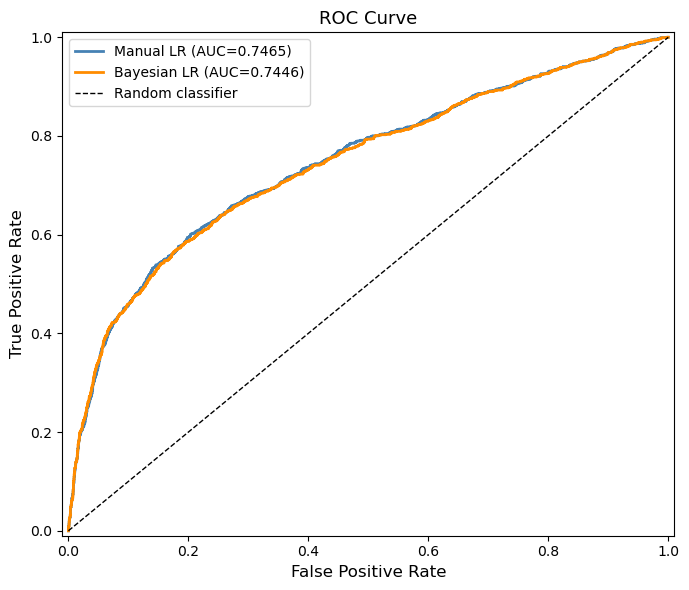

In [66]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(7, 6))

# Manual LR
fpr_freq, tpr_freq, _ = roc_curve(y_true, proba_freq)
auc_freq = auc(fpr_freq, tpr_freq)
ax.plot(fpr_freq, tpr_freq, color='steelblue', linewidth=2,
        label=f'Manual LR (AUC={auc_freq:.4f})')

# Bayesian LR
fpr_bayes, tpr_bayes, _ = roc_curve(y_true, proba_bayes)
auc_bayes = auc(fpr_bayes, tpr_bayes)
ax.plot(fpr_bayes, tpr_bayes, color='darkorange', linewidth=2,
        label=f'Bayesian LR (AUC={auc_bayes:.4f})')

# Random classifier
ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random classifier')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()

## Exhibit 7: Precision-Recall Curve

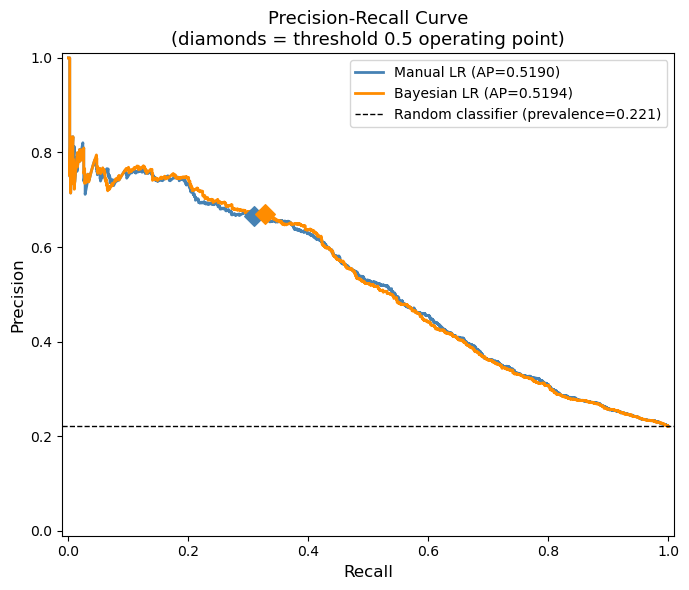

Operating point at threshold=0.5:
  Manual LR  — Precision=0.6661  Recall=0.3097
  Bayesian LR — Precision=0.6698  Recall=0.3271


In [69]:
from sklearn.metrics import precision_recall_curve, auc

fig, ax = plt.subplots(figsize=(7, 6))

# Manual LR
prec_freq, rec_freq, thr_freq = precision_recall_curve(y_true, proba_freq)
ap_freq = auc(rec_freq, prec_freq)
ax.plot(rec_freq, prec_freq, color='steelblue', linewidth=2,
        label=f'Manual LR (AP={ap_freq:.4f})')
idx_05_freq = np.argmin(np.abs(thr_freq - 0.5))
ax.scatter(rec_freq[idx_05_freq], prec_freq[idx_05_freq],
           color='steelblue', s=100, zorder=5, marker='D')

# Bayesian LR
prec_bayes, rec_bayes, thr_bayes = precision_recall_curve(y_true, proba_bayes)
ap_bayes = auc(rec_bayes, prec_bayes)
ax.plot(rec_bayes, prec_bayes, color='darkorange', linewidth=2,
        label=f'Bayesian LR (AP={ap_bayes:.4f})')
idx_05_bayes = np.argmin(np.abs(thr_bayes - 0.5))
ax.scatter(rec_bayes[idx_05_bayes], prec_bayes[idx_05_bayes],
           color='darkorange', s=100, zorder=5, marker='D')

# Baseline
baseline = y_true.mean()
ax.axhline(baseline, color='k', linestyle='--', linewidth=1,
           label=f'Random classifier (prevalence={baseline:.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve\n'
             '(diamonds = threshold 0.5 operating point)', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
plt.tight_layout()
plt.savefig("pr_curve.png", dpi=150)
plt.show()

# Operating point stats
print("Operating point at threshold=0.5:")
print(f"  Manual LR  — Precision={prec_freq[idx_05_freq]:.4f}"
      f"  Recall={rec_freq[idx_05_freq]:.4f}")
print(f"  Bayesian LR — Precision={prec_bayes[idx_05_bayes]:.4f}"
      f"  Recall={rec_bayes[idx_05_bayes]:.4f}")

## Exhibit 8: Profile A — Borderline Borrower

Profile A — index: 1058
  Posterior mean:  0.4183
  95% CI:          [0.2936, 0.5409]
  CI width:        0.2473
  Frequentist est: 0.3647
  True outcome:    1


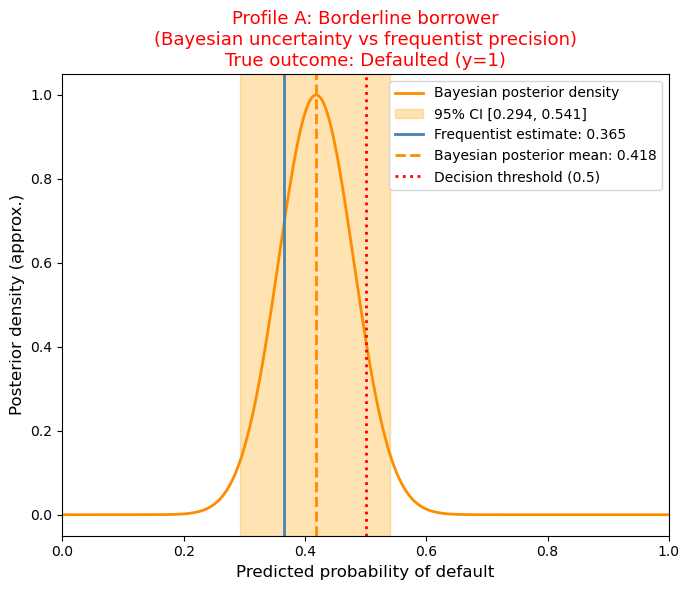

In [72]:
# ── Select Profile A ──────────────────────────────────────────────────────────
ci_width_arr = ci_upper - ci_lower
ci_75th      = np.percentile(ci_width_arr, 75)

mask_A = (proba_bayes >= 0.40) & (proba_bayes <= 0.60) & \
         (ci_width_arr >= ci_75th)
if mask_A.sum() > 0:
    idx_A = np.where(mask_A)[0][np.argmax(ci_width_arr[mask_A])]
else:
    mask_A = (proba_bayes >= 0.40) & (proba_bayes <= 0.60)
    idx_A  = np.where(mask_A)[0][np.argmax(ci_width_arr[mask_A])]

print(f"Profile A — index: {idx_A}")
print(f"  Posterior mean:  {proba_bayes[idx_A]:.4f}")
print(f"  95% CI:          [{ci_lower[idx_A]:.4f}, {ci_upper[idx_A]:.4f}]")
print(f"  CI width:        {ci_width_arr[idx_A]:.4f}")
print(f"  Frequentist est: {proba_freq[idx_A]:.4f}")
print(f"  True outcome:    {y_true[idx_A]}")

# ── Posterior density approximation ───────────────────────────────────────────
mu_A    = proba_bayes[idx_A]
sigma_A = (ci_upper[idx_A] - ci_lower[idx_A]) / 4
x_A     = np.linspace(0, 1, 500)
density_A = np.exp(-0.5 * ((x_A - mu_A) / sigma_A) ** 2)
density_A /= density_A.max()

# ── Plot ──────────────────────────────────────────────────────────────────────
outcome_label_A = 'Defaulted (y=1)' if y_true[idx_A] == 1 \
                  else 'Did not default (y=0)'
outcome_color_A = 'red' if y_true[idx_A] == 1 else 'green'

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(x_A, density_A, color='darkorange', linewidth=2,
        label='Bayesian posterior density')
ax.axvspan(ci_lower[idx_A], ci_upper[idx_A],
           color='orange', alpha=0.3,
           label=f'95% CI [{ci_lower[idx_A]:.3f}, {ci_upper[idx_A]:.3f}]')
ax.axvline(proba_freq[idx_A], color='steelblue', linewidth=2,
           label=f'Frequentist estimate: {proba_freq[idx_A]:.3f}')
ax.axvline(proba_bayes[idx_A], color='darkorange', linestyle='--', linewidth=2,
           label=f'Bayesian posterior mean: {proba_bayes[idx_A]:.3f}')
ax.axvline(0.5, color='red', linestyle=':', linewidth=2,
           label='Decision threshold (0.5)')

ax.set_xlabel('Predicted probability of default', fontsize=12)
ax.set_ylabel('Posterior density (approx.)', fontsize=12)
ax.set_title(
    'Profile A: Borderline borrower\n'
    '(Bayesian uncertainty vs frequentist precision)\n'
    f'True outcome: {outcome_label_A}',
    fontsize=13,
    color=outcome_color_A
)
ax.legend(fontsize=10)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig("borrower_profile_A.png", dpi=150)
plt.show()

## Exhibit 9: Profile B — High-Confidence Wrong Prediction

Profile B — index: 850
  Posterior mean:  0.9929
  95% CI:          [0.9908, 0.9947]
  CI width:        0.0039
  Frequentist est: 0.9914
  True outcome:    0


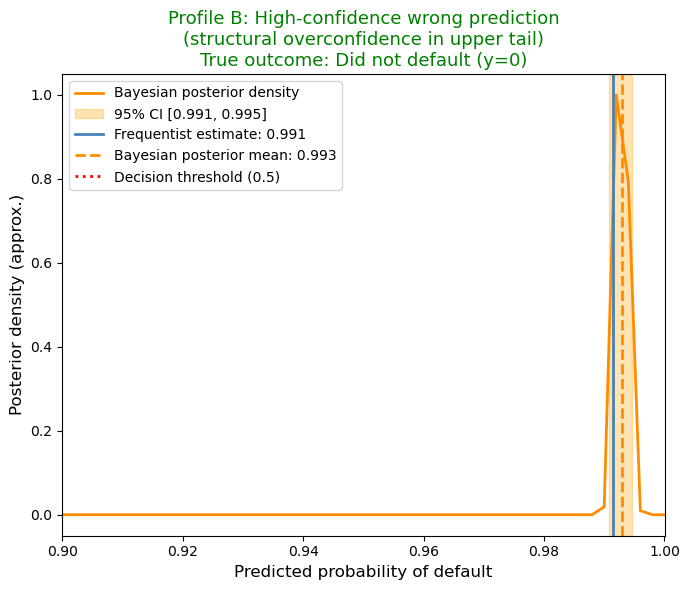

In [73]:
# ── Select Profile B ──────────────────────────────────────────────────────────
mask_B = (proba_bayes >= 0.80) & (y_true == 0)
if mask_B.sum() > 0:
    idx_B = np.where(mask_B)[0][np.argmax(proba_bayes[mask_B])]
else:
    mask_B = (proba_bayes >= 0.5) & (y_true == 0)
    idx_B  = np.where(mask_B)[0][np.argmax(proba_bayes[mask_B])]

print(f"Profile B — index: {idx_B}")
print(f"  Posterior mean:  {proba_bayes[idx_B]:.4f}")
print(f"  95% CI:          [{ci_lower[idx_B]:.4f}, {ci_upper[idx_B]:.4f}]")
print(f"  CI width:        {ci_width_arr[idx_B]:.4f}")
print(f"  Frequentist est: {proba_freq[idx_B]:.4f}")
print(f"  True outcome:    {y_true[idx_B]}")

# ── Posterior density approximation ───────────────────────────────────────────
mu_B    = proba_bayes[idx_B]
sigma_B = (ci_upper[idx_B] - ci_lower[idx_B]) / 4
x_B     = np.linspace(0, 1, 500)
density_B = np.exp(-0.5 * ((x_B - mu_B) / sigma_B) ** 2)
density_B /= density_B.max()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(x_B, density_B, color='darkorange', linewidth=2,
        label='Bayesian posterior density')
ax.axvspan(ci_lower[idx_B], ci_upper[idx_B],
           color='orange', alpha=0.3,
           label=f'95% CI [{ci_lower[idx_B]:.3f}, {ci_upper[idx_B]:.3f}]')
ax.axvline(proba_freq[idx_B], color='steelblue', linewidth=2,
           label=f'Frequentist estimate: {proba_freq[idx_B]:.3f}')
ax.axvline(proba_bayes[idx_B], color='darkorange', linestyle='--', linewidth=2,
           label=f'Bayesian posterior mean: {proba_bayes[idx_B]:.3f}')
ax.axvline(0.5, color='red', linestyle=':', linewidth=2,
           label='Decision threshold (0.5)')

ax.set_xlim(0.90, 1.00)
ax.set_xlabel('Predicted probability of default', fontsize=12)
ax.set_ylabel('Posterior density (approx.)', fontsize=12)
ax.set_title(
    'Profile B: High-confidence wrong prediction\n'
    '(structural overconfidence in upper tail)\n'
    f'True outcome: Did not default (y={y_true[idx_B]})',
    fontsize=13,
    color='green'
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("borrower_profile_B.png", dpi=150)
plt.show()